# Step-by-Step Belief Propagation Tutorial

This notebook demonstrates the **StepByStepFormatter** for visualizing belief propagation
message passing in a pedagogical, Excel-like format.

## What You'll Learn
1. How to create a simple factor graph
2. How to run BP and capture snapshots
3. How to format and display step-by-step output
4. How to add unary constraints (priors)

In [1]:
import numpy as np
from propflow import FGBuilder, BPEngine, MinSumComputator
from propflow.configs import create_random_int_table
from propflow.snapshots import StepByStepFormatter

## 1. Create a Simple Factor Graph

We'll create a 3-variable cycle graph with domain size 2 (values: a, b).
This matches the structure in the Excel example.

Variables: ['x1', 'x2', 'x3']
Factors: ['f12', 'f23', 'f31']


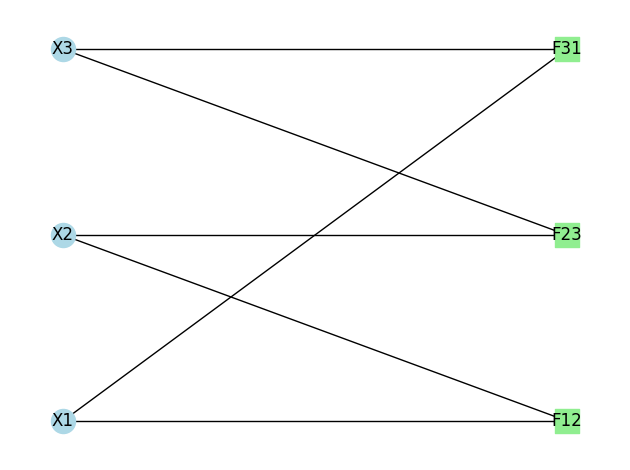

In [2]:
# create a cycle graph: x1 -- f12 -- x2 -- f23 -- x3 -- f31 -- x1
fg = FGBuilder.build_cycle_graph(
    num_vars=3,
    domain_size=2,
    ct_factory=create_random_int_table,
    ct_params={"low": 0, "high": 10},
)

print(f"Variables: {[v.name for v in fg.variables]}")
print(f"Factors: {[f.name for f in fg.factors]}")

# visualize the graph structure
fg.visualize()

## 2. Run Belief Propagation

We run Min-Sum BP for a few iterations. The engine automatically captures
snapshots of the state at each step.

In [3]:
# create and run the BP engine
engine = BPEngine(fg, computator=MinSumComputator())
engine.run(max_iter=5)

print(f"Completed {engine.iteration_count} iterations")
print(f"Final assignments: {engine.assignments}")
print(f"Final cost: {engine.calculate_global_cost()}")

Completed 5 iterations
Final assignments: {'x1': 0, 'x2': 1, 'x3': 0}
Final cost: 6.0


## 3. Step-by-Step Output

The `StepByStepFormatter` provides a pedagogical view of the BP algorithm,
showing cost tables, Q/R messages, and assignments at each iteration.

In [4]:
# create the formatter from engine snapshots
formatter = StepByStepFormatter(engine.snapshots)

# show cost tables for all factors
print(formatter.format_cost_tables())

COST TABLES

Factor: F12
  Connected variables: x1, x2
         a      b
  a      0      0
  b      7      4

Factor: F23
  Connected variables: x2, x3
         a      b
  a      8      7
  b      5      1

Factor: F31
  Connected variables: x3, x1
         a      b
  a      1      5
  b      2      1



In [ ]:
# show a single iteration in detail
print(formatter.format_iteration(0))

In [ ]:
# show full step-by-step output
print(formatter.format_all_steps())

In [ ]:
# show summary
print(formatter.format_summary())

## 4. Adding Unary Constraints (Priors)

Unary factors act as per-variable biases. They're useful for adding
soft preferences on variable assignments.

In [ ]:
# define unary costs (lower = preferred)
unary_costs = {
    "x1": np.array([0, 10]),   # strongly prefer x1 = a
    "x3": np.array([10, 0]),   # strongly prefer x3 = b
}

# create graph with unary factors
fg_unary = FGBuilder.build_with_unary_costs(fg, unary_costs)

print(f"Factors (with unary): {[f.name for f in fg_unary.factors]}")

In [ ]:
# run BP on graph with unary constraints
engine_unary = BPEngine(fg_unary, computator=MinSumComputator())
engine_unary.run(max_iter=5)

# format output
formatter_unary = StepByStepFormatter(engine_unary.snapshots)
print(formatter_unary.format_cost_tables())
print(formatter_unary.format_summary())

## 5. Compare Iterations

You can examine how messages evolve across iterations.

In [ ]:
# compare specific iterations side by side
for step in [0, 2, 4]:
    print(f"\n{'='*60}")
    print(formatter.format_iteration(step))

## Summary

The `StepByStepFormatter` provides:
- `format_cost_tables()` - Display all factor cost tables
- `format_iteration(step)` - Show Q/R messages for a specific iteration
- `format_all_steps()` - Complete step-by-step output
- `format_summary()` - Compact summary with initial/final costs

The `FGBuilder.build_with_unary_costs()` method adds unary factors for per-variable biases.